Potencia de ruido (pr): 0.005


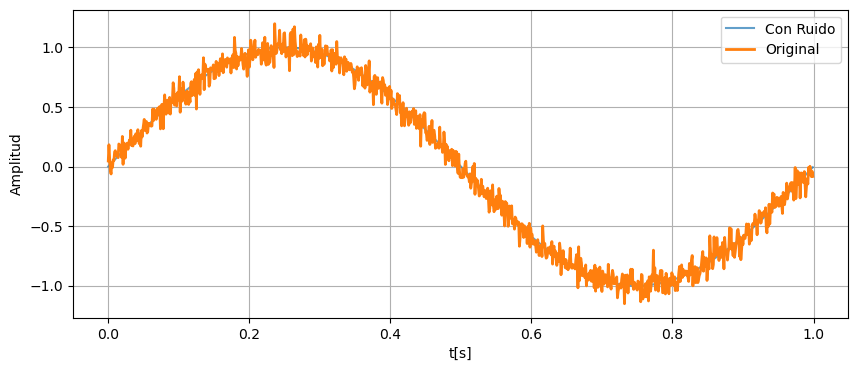

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    # Usamos np.arange(nn) para asegurar exactamente 'nn' muestras
    tt = np.arange(0, nn) * ts 
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

def mi_funcion_sen_ruido(vmax, dc, ff, ph, nn, fs, snr, pr):
    ts = 1/fs
    tt = np.arange(0, nn) * ts
    desvio = np.sqrt(pr)
    r = np.random.normal(0, desvio, len(tt)) # lo del medio es el desvio estandar
    #verifico el valor de la varianza de r a ver si calcule bien
    print(f"Potencia de ruido (pr): {pr}") # esto es la potencia de ruido
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    xx1 = xx + r
    return tt, xx1

# Parámetros
A = 1 
dc = 0
fs = 1000
f0 = 1
fase = 0
muestras = 1000
snr = 20 #db
Ps = (A**2)/ 2
pr = Ps / (10**(snr/10)) #ESTO DEBERIA SER LA VARIANZA

# Llamadas a las funciones
tt, xx1 = mi_funcion_sen_ruido(A, dc, f0, fase, muestras, fs, snr, pr)
tt1, xx = mi_funcion_sen(A, dc, f0, fase, muestras, fs)

# Gráfico
plt.figure(figsize=(10, 4))
plt.plot(tt, xx, label="Con Ruido", alpha=0.7)
plt.plot(tt1, xx1, label="Original", linewidth=2)
plt.xlabel("t[s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend()
plt.show()

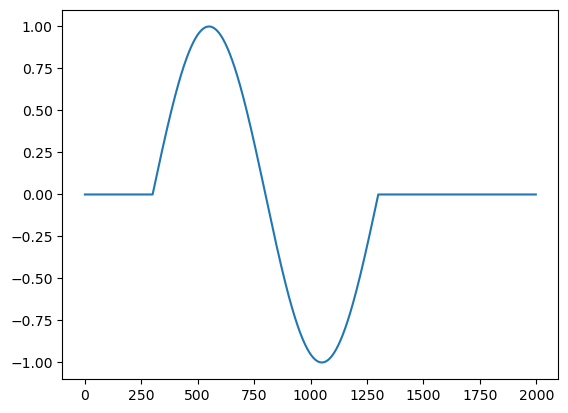

In [6]:
#%% 
from scipy import signal as sig

n0 = 300
#creo un delta de cronequer
dd = np.zeros(muestras)
dd[n0] = 1.

yy = sig.convolve(xx, dd)

plt.figure(2)
plt.clf()
plt.plot(yy)

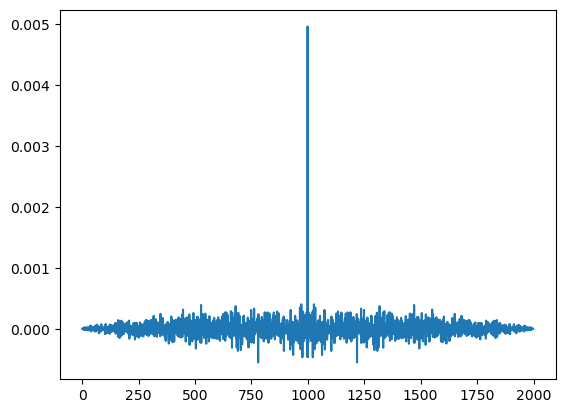

In [4]:
#%%
desvio = np.sqrt(pr)
ruido = np.random.normal(0, desvio, len(tt)) # lo del medio es el desvio estandar

yy1 = 1/muestras * sig.convolve(ruido, np.flip(ruido)) 

plt.figure(3)
plt.clf()
plt.plot(yy1)

yy: [0. 0. 0. ... 0. 0. 0.]
qq: 0.375


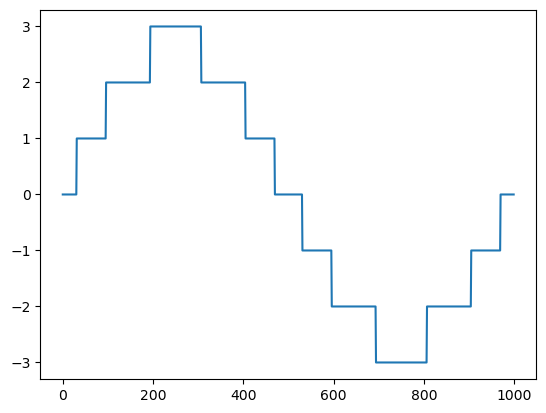

In [3]:
#%% 
B = 3  # bits
Vfs = 3  # Volts

qq = Vfs / (2**B)

print("yy:", yy)
print("qq:", qq)


xxq = np.round(xx / qq)

plt.figure(8)
plt.plot(xxq)